# Metals 5-Minute Trade Mahalanobis Distance

This notebook aggregates the 3-year raw metals trade prints to 5-minute bars and computes Mahalanobis distance time series on trade-flow vectors.

Source:

`/home/famadeo/research/databento-asset-browser/data/metals_trades_3y_core/outright`

Primary distance: EWMA Mahalanobis distance of signed-notional shares, where `B = +`, `A = -`, and `N = 0`, normalized by total complex notional in the 5-minute bar. A second distance on unsigned notional participation shares is included as a concentration/control view.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

from quantlab.metals_flow.anomaly import mahalanobis_distances
from quantlab.metals_flow.config import CONTRACT_MULTIPLIERS

plt.style.use("seaborn-v0_8-whitegrid")

TRADE_DIR = Path("/home/famadeo/research/databento-asset-browser/data/metals_trades_3y_core/outright")
ROOTS = ["GC", "SI", "HG", "PL", "PA"]
BAR_SIZE = "5m"
EWMA_HALFLIFE_BARS = 2016  # roughly one calendar week of 5-minute bars
MIN_PERIODS = 2016
ASSET_DIR = Path("assets/2026-06-25_metals_5m_trade_mahalanobis")
ASSET_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_rows", 80)
pd.set_option("display.max_columns", 80)

## Aggregate Trades To 5-Minute Bars

The aggregation is root-by-root and only materializes 5-minute totals, not the full 153M-row raw trade table.

In [2]:
def aggregate_root_5m(root: str) -> pd.DataFrame:
    path = TRADE_DIR / f"{root}.parquet"
    if not path.exists():
        raise FileNotFoundError(path)
    multiplier = float(CONTRACT_MULTIPLIERS[root])
    sign = (
        pl.when(pl.col("side") == "B").then(pl.lit(1.0))
        .when(pl.col("side") == "A").then(pl.lit(-1.0))
        .otherwise(pl.lit(0.0))
        .alias("aggressor_sign")
    )
    frame = (
        pl.scan_parquet(path)
        .select("ts_event", "price", "size", "side")
        .with_columns(
            pl.col("ts_event").dt.truncate(BAR_SIZE).alias("ts"),
            pl.col("price").cast(pl.Float64).alias("price"),
            pl.col("size").cast(pl.Float64).alias("size"),
            sign,
        )
        .with_columns((pl.col("price") * pl.col("size") * multiplier).alias("notional"))
        .with_columns((pl.col("notional") * pl.col("aggressor_sign")).alias("signed_notional"))
        .group_by("ts")
        .agg(
            pl.len().alias(f"{root}_trades"),
            pl.col("size").sum().alias(f"{root}_contracts"),
            pl.col("notional").sum().alias(f"{root}_notional"),
            pl.col("signed_notional").sum().alias(f"{root}_signed_notional"),
            (pl.col("side") == "B").sum().alias(f"{root}_buy_trades"),
            (pl.col("side") == "A").sum().alias(f"{root}_sell_trades"),
            (pl.col("side") == "N").sum().alias(f"{root}_neutral_trades"),
        )
        .sort("ts")
        .collect()
        .to_pandas()
    )
    frame["ts"] = pd.to_datetime(frame["ts"], utc=True)
    return frame.set_index("ts")


parts = [aggregate_root_5m(root) for root in ROOTS]
bars = pd.concat(parts, axis=1).sort_index().fillna(0.0)

notional_cols = [f"{root}_notional" for root in ROOTS]
signed_cols = [f"{root}_signed_notional" for root in ROOTS]
trade_cols = [f"{root}_trades" for root in ROOTS]
contract_cols = [f"{root}_contracts" for root in ROOTS]

bars["complex_notional"] = bars[notional_cols].sum(axis=1)
bars["complex_signed_notional"] = bars[signed_cols].sum(axis=1)
bars["complex_trades"] = bars[trade_cols].sum(axis=1)
bars["complex_contracts"] = bars[contract_cols].sum(axis=1)
bars = bars.loc[bars["complex_trades"] > 0].copy()
bars.to_parquet(ASSET_DIR / "metals_trade_flow_5m.parquet")

inventory = pd.DataFrame(
    {
        "metric": ["bars", "start", "end", "trades", "contracts", "notional"],
        "value": [
            len(bars),
            bars.index.min(),
            bars.index.max(),
            int(bars["complex_trades"].sum()),
            float(bars["complex_contracts"].sum()),
            float(bars["complex_notional"].sum()),
        ],
    }
)
inventory.to_csv(ASSET_DIR / "trade_flow_5m_inventory.csv", index=False)
inventory

,metric,value
0,bars,212363
1,start,2023-06-22 00:00:00+00:00
2,end,2026-06-21 23:55:00+00:00
3,trades,153330532
4,contracts,260101362.0
5,notional,60676991791520.0


## Build Trade-Flow Vectors

- `signed_flow_share`: root signed notional divided by total complex notional in the bar.
- `notional_share`: root unsigned notional divided by total complex notional in the bar.

The signed vector is the primary trade-dislocation cloud. The unsigned vector shows concentration of participation across roots.

In [3]:
denominator = bars["complex_notional"].replace(0.0, np.nan)
signed_flow_share = pd.DataFrame(index=bars.index)
notional_share = pd.DataFrame(index=bars.index)
for root in ROOTS:
    signed_flow_share[root] = bars[f"{root}_signed_notional"] / denominator
    notional_share[root] = bars[f"{root}_notional"] / denominator

signed_flow_share = signed_flow_share.replace([np.inf, -np.inf], np.nan).fillna(0.0)
notional_share = notional_share.replace([np.inf, -np.inf], np.nan).fillna(0.0)

signed_flow_share.to_parquet(ASSET_DIR / "signed_flow_share_5m.parquet")
notional_share.to_parquet(ASSET_DIR / "notional_share_5m.parquet")

signed_flow_share.head()

,GC,SI,HG,PL,PA
ts,,,,,
2023-06-22 00:00:00+00:00,-0.173009,-0.024775,-0.030129,0.012060,0.0
2023-06-22 00:05:00+00:00,0.050289,-0.046427,-0.021707,0.003519,0.0
2023-06-22 00:10:00+00:00,0.186560,0.009952,0.021294,0.103553,0.0
2023-06-22 00:15:00+00:00,-0.057522,0.021050,0.072279,0.010592,0.0
2023-06-22 00:20:00+00:00,-0.230321,0.007765,-0.002226,-0.004334,0.0


## Compute EWMA Mahalanobis Distance

Distances are computed prequentially by the helper: each bar is scored against the EWMA center/covariance estimated from prior bars, then the state is updated.

In [4]:
md = pd.DataFrame(index=bars.index)
md["md_signed_flow_ewma"] = mahalanobis_distances(
    signed_flow_share,
    method="ewma",
    ewma_halflife=EWMA_HALFLIFE_BARS,
    min_periods=MIN_PERIODS,
    ridge=1e-6,
)
md["md_notional_share_ewma"] = mahalanobis_distances(
    notional_share,
    method="ewma",
    ewma_halflife=EWMA_HALFLIFE_BARS,
    min_periods=MIN_PERIODS,
    ridge=1e-6,
)
for column in ["md_signed_flow_ewma", "md_notional_share_ewma"]:
    md[f"{column}_q95"] = md[column].dropna().quantile(0.95)
    md[f"{column}_q99"] = md[column].dropna().quantile(0.99)
    md[f"{column}_q995"] = md[column].dropna().quantile(0.995)

md["complex_trades"] = bars["complex_trades"]
md["complex_notional"] = bars["complex_notional"]
md["complex_signed_notional_ratio"] = bars["complex_signed_notional"] / denominator
md.to_csv(ASSET_DIR / "trade_mahalanobis_5m.csv")
md.describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.995, 0.999])

,md_signed_flow_ewma,md_notional_share_ewma,md_signed_flow_ewma_q95,md_signed_flow_ewma_q99,md_signed_flow_ewma_q995,md_notional_share_ewma_q95,md_notional_share_ewma_q99,md_notional_share_ewma_q995,complex_trades,complex_notional,complex_signed_notional_ratio
count,210347.000000,210347.000000,2.123630e+05,212363.000000,2.123630e+05,2.123630e+05,2.123630e+05,2.123630e+05,212363.000000,2.123630e+05,212363.000000
mean,1.856726,1.645097,4.042793e+00,6.374855,7.602299e+00,3.663681e+00,6.128977e+00,7.490015e+00,722.020936,2.857230e+08,0.000744
std,1.254154,1.149581,8.881805e-16,0.000000,3.552722e-15,4.440903e-16,8.881805e-16,1.776361e-15,786.600616,3.647742e+08,0.134526
min,0.032211,0.081526,4.042793e+00,6.374855,7.602299e+00,3.663681e+00,6.128977e+00,7.490015e+00,9.000000,1.274955e+06,-0.802810
50%,1.574683,1.344529,4.042793e+00,6.374855,7.602299e+00,3.663681e+00,6.128977e+00,7.490015e+00,473.000000,1.728232e+08,-0.000153
90%,3.237147,2.824694,4.042793e+00,6.374855,7.602299e+00,3.663681e+00,6.128977e+00,7.490015e+00,1569.000000,6.331542e+08,0.166289
95%,4.042793,3.663681,4.042793e+00,6.374855,7.602299e+00,3.663681e+00,6.128977e+00,7.490015e+00,2146.000000,9.013058e+08,0.220966
99%,6.374855,6.128977,4.042793e+00,6.374855,7.602299e+00,3.663681e+00,6.128977e+00,7.490015e+00,3813.000000,1.745039e+09,0.338740
99.5%,7.602299,7.490015,4.042793e+00,6.374855,7.602299e+00,3.663681e+00,6.128977e+00,7.490015e+00,4696.190000,2.218757e+09,0.382671
99.9%,11.978226,11.411040,4.042793e+00,6.374855,7.602299e+00,3.663681e+00,6.128977e+00,7.490015e+00,7290.552000,3.612101e+09,0.490485


## Full-Timeframe View

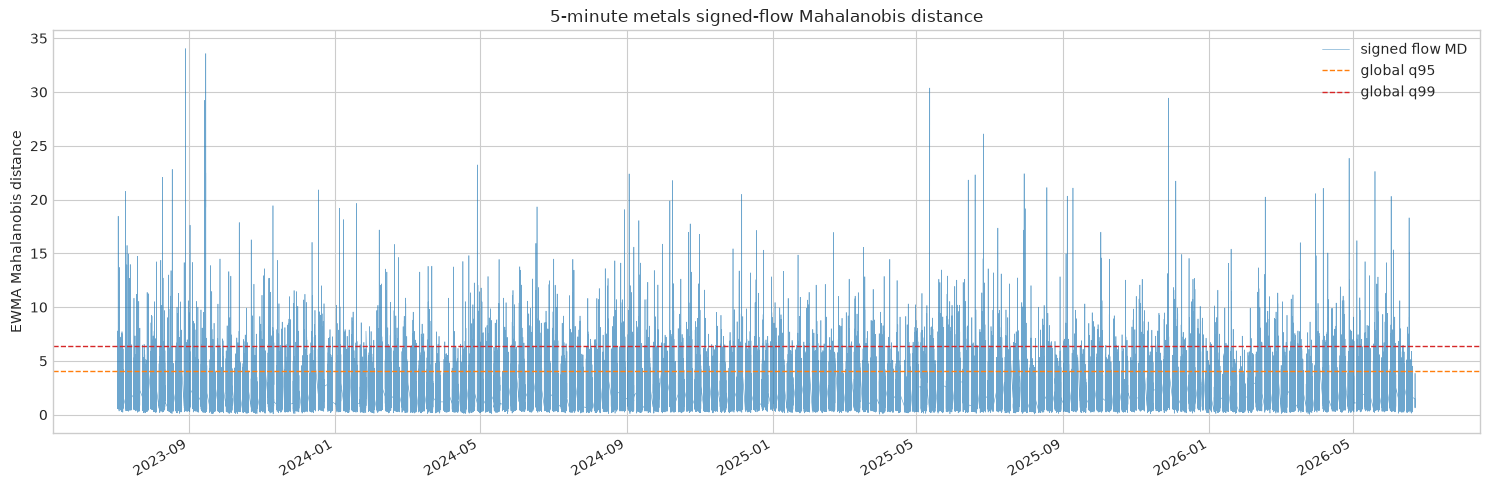

In [5]:
fig, ax = plt.subplots(figsize=(15, 5))
md["md_signed_flow_ewma"].plot(ax=ax, linewidth=0.45, alpha=0.65, label="signed flow MD")
ax.axhline(md["md_signed_flow_ewma_q95"].iloc[0], color="tab:orange", linestyle="--", linewidth=1, label="global q95")
ax.axhline(md["md_signed_flow_ewma_q99"].iloc[0], color="tab:red", linestyle="--", linewidth=1, label="global q99")
ax.set_title("5-minute metals signed-flow Mahalanobis distance")
ax.set_xlabel("")
ax.set_ylabel("EWMA Mahalanobis distance")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(ASSET_DIR / "md_signed_flow_5m_timeseries.png", dpi=160)
plt.show()

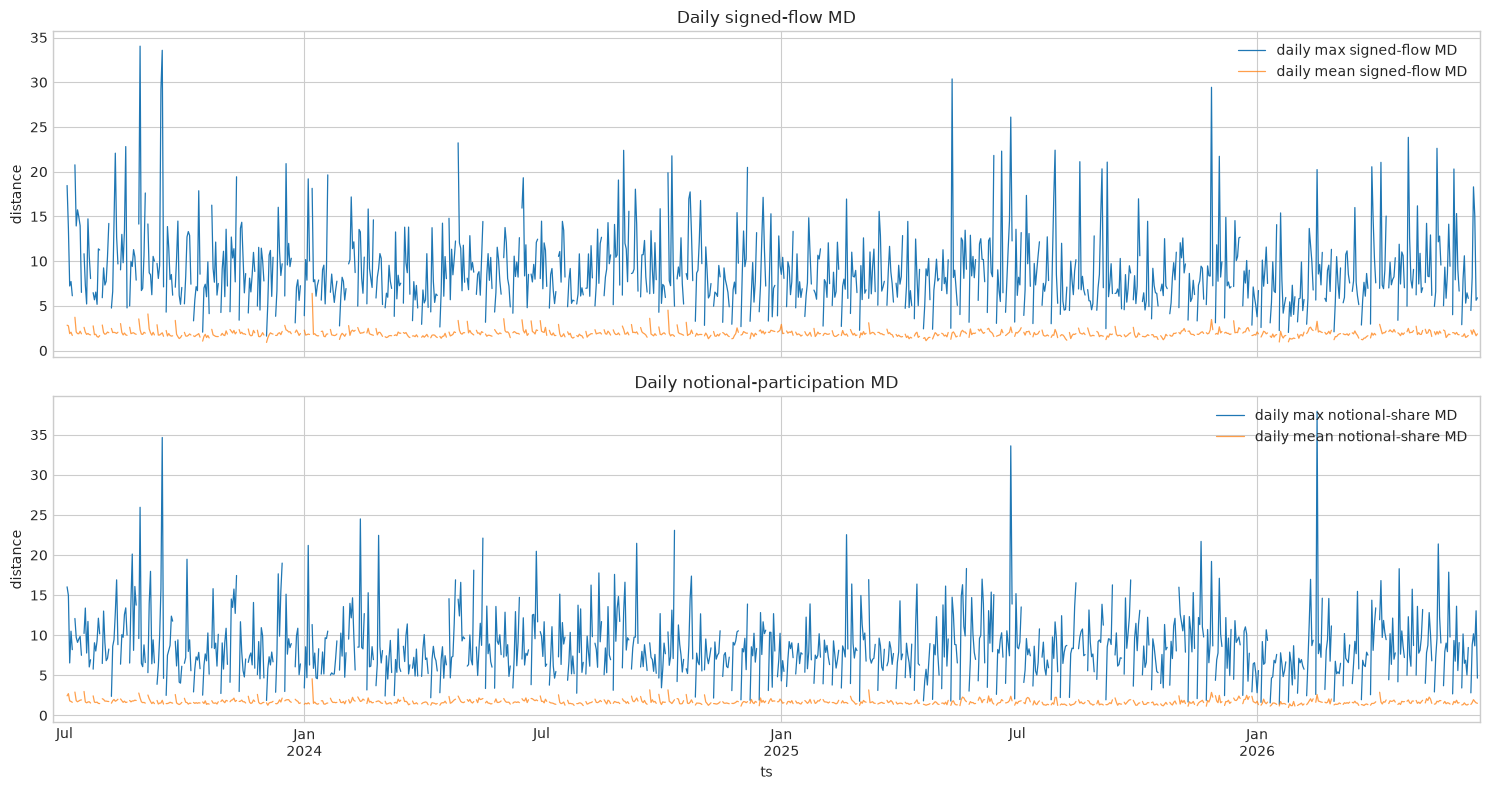

In [6]:
daily = md[["md_signed_flow_ewma", "md_notional_share_ewma"]].resample("1D").agg(["max", "mean"])
daily.columns = ["_".join(col).strip("_") for col in daily.columns]
daily.to_csv(ASSET_DIR / "trade_mahalanobis_daily_summary.csv")

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
daily["md_signed_flow_ewma_max"].plot(ax=axes[0], linewidth=0.9, label="daily max signed-flow MD")
daily["md_signed_flow_ewma_mean"].plot(ax=axes[0], linewidth=0.9, alpha=0.75, label="daily mean signed-flow MD")
axes[0].set_title("Daily signed-flow MD")
axes[0].set_ylabel("distance")
axes[0].legend(loc="upper right")

daily["md_notional_share_ewma_max"].plot(ax=axes[1], linewidth=0.9, label="daily max notional-share MD")
daily["md_notional_share_ewma_mean"].plot(ax=axes[1], linewidth=0.9, alpha=0.75, label="daily mean notional-share MD")
axes[1].set_title("Daily notional-participation MD")
axes[1].set_ylabel("distance")
axes[1].legend(loc="upper right")

fig.tight_layout()
fig.savefig(ASSET_DIR / "trade_mahalanobis_daily_summary.png", dpi=160)
plt.show()

## Extreme 5-Minute Trade-Flow Events

In [7]:
event_frame = pd.concat(
    [
        md[["md_signed_flow_ewma", "md_notional_share_ewma", "complex_trades", "complex_notional", "complex_signed_notional_ratio"]],
        signed_flow_share.add_prefix("signed_share_"),
        notional_share.add_prefix("notional_share_"),
    ],
    axis=1,
)
top_events = event_frame.sort_values("md_signed_flow_ewma", ascending=False).head(250)
top_events.to_csv(ASSET_DIR / "top_signed_flow_md_events.csv")
top_events.head(25).style.format(
    {
        "md_signed_flow_ewma": "{:.2f}",
        "md_notional_share_ewma": "{:.2f}",
        "complex_trades": "{:.0f}",
        "complex_notional": "{:,.0f}",
        "complex_signed_notional_ratio": "{:.2%}",
        **{f"signed_share_{root}": "{:.2%}" for root in ROOTS},
        **{f"notional_share_{root}": "{:.2%}" for root in ROOTS},
    }
)

,md_signed_flow_ewma,md_notional_share_ewma,complex_trades,complex_notional,complex_signed_notional_ratio,signed_share_GC,signed_share_SI,signed_share_HG,signed_share_PL,signed_share_PA,notional_share_GC,notional_share_SI,notional_share_HG,notional_share_PL,notional_share_PA
ts,,,,,,,,,,,,,,,
2023-08-28 23:15:00+00:00,34.03,25.95,53,"6,898,828",-28.23%,8.47%,-1.76%,1.39%,-38.16%,1.82%,8.47%,1.76%,17.88%,66.43%,5.47%
2023-09-14 22:55:00+00:00,33.57,34.66,84,"14,768,895",-30.00%,6.54%,-2.33%,-3.23%,-7.40%,-23.58%,22.24%,6.99%,4.53%,12.33%,53.92%
2025-05-12 04:50:00+00:00,30.37,14.74,335,"121,505,948",15.03%,-2.43%,-0.27%,-1.83%,19.56%,0.00%,64.58%,3.81%,8.70%,22.91%,0.00%
2025-11-27 18:40:00+00:00,29.43,9.23,51,"17,389,718",-5.06%,19.27%,-6.19%,-0.74%,-18.24%,0.85%,55.41%,24.77%,0.74%,18.24%,0.85%
2023-09-13 22:35:00+00:00,29.22,15.81,57,"17,086,318",61.19%,24.86%,-2.03%,-0.00%,38.36%,0.00%,49.72%,2.03%,2.22%,46.04%,0.00%
2025-06-26 02:10:00+00:00,26.10,33.61,306,"86,174,550",23.12%,8.15%,5.94%,0.29%,-2.65%,11.40%,45.41%,14.84%,0.29%,9.57%,29.88%
2026-04-27 20:10:00+00:00,23.84,12.31,71,"21,576,640",38.24%,10.90%,10.50%,0.00%,16.16%,0.69%,52.22%,22.80%,3.52%,20.78%,0.69%
2024-04-28 23:45:00+00:00,23.22,14.50,115,"27,410,775",9.05%,11.11%,2.01%,3.77%,-0.50%,-7.33%,46.27%,11.53%,25.12%,5.56%,11.52%
2023-08-17 22:55:00+00:00,22.81,13.41,48,"8,835,488",2.92%,-17.42%,-2.56%,1.04%,21.86%,0.00%,54.36%,10.38%,7.30%,27.96%,0.00%


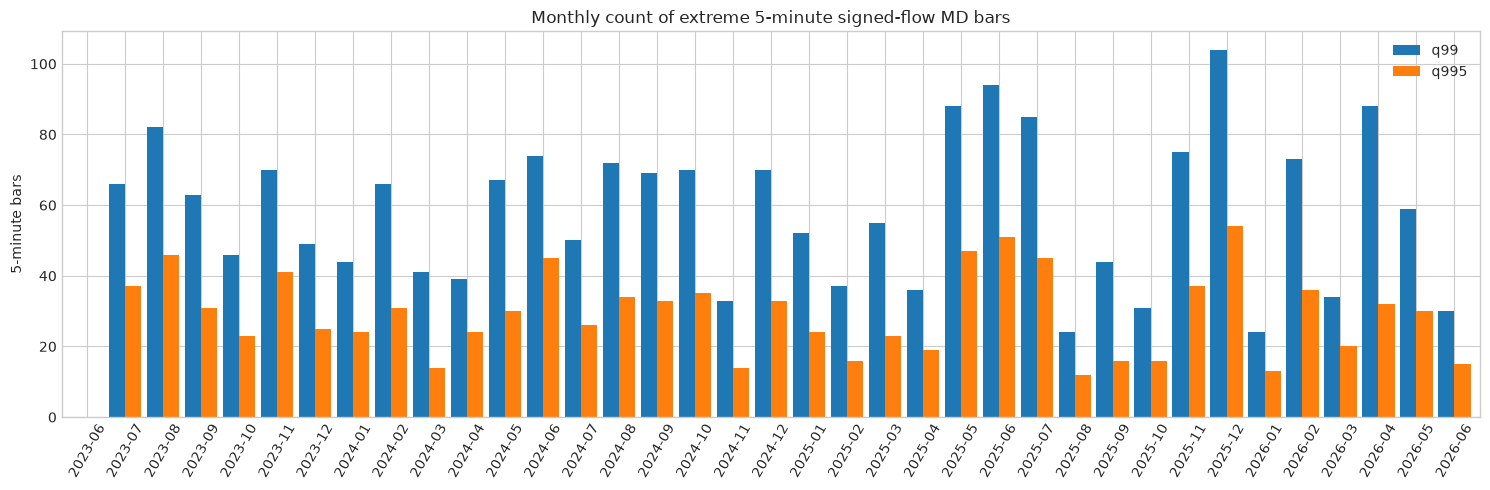

,q95,q99,q995
ts,,,
2025-07,350,85,45
2025-08,214,24,12
2025-09,233,44,16
2025-10,184,31,16
2025-11,387,75,37
2025-12,400,104,54
2026-01,159,24,13
2026-02,386,73,36
2026-03,212,34,20


In [8]:
event_counts = pd.DataFrame(index=md.index)
event_counts["q95"] = md["md_signed_flow_ewma"] >= md["md_signed_flow_ewma_q95"].iloc[0]
event_counts["q99"] = md["md_signed_flow_ewma"] >= md["md_signed_flow_ewma_q99"].iloc[0]
event_counts["q995"] = md["md_signed_flow_ewma"] >= md["md_signed_flow_ewma_q995"].iloc[0]
monthly_counts = event_counts.resample("ME").sum().astype(int)
monthly_counts.index = monthly_counts.index.strftime("%Y-%m")
monthly_counts.to_csv(ASSET_DIR / "monthly_signed_flow_md_event_counts.csv")

fig, ax = plt.subplots(figsize=(15, 5))
monthly_counts[["q99", "q995"]].plot(kind="bar", ax=ax, width=0.85)
ax.set_title("Monthly count of extreme 5-minute signed-flow MD bars")
ax.set_xlabel("")
ax.set_ylabel("5-minute bars")
ax.tick_params(axis="x", labelrotation=60)
fig.tight_layout()
fig.savefig(ASSET_DIR / "monthly_signed_flow_md_event_counts.png", dpi=160)
plt.show()

monthly_counts.tail(12)